# Figures for JPO Paper

In [40]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cmocean.cm as cmo
import cartopy.crs as ccrs
import gsw

In [41]:
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']  = 18
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

## Load Datasets

In [3]:
ds_pbar = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_var.nc')

In [4]:
ds_pbar_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_var.nc')
ds_pbar_grad = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grad_cip_masking.nc')

In [5]:
ds_pbar_grid = ds_pbar_grid.assign_coords(LON_left = ds_pbar_grad.LON_left,LAT_left = ds_pbar_grad.LAT_left)
ds_pbar_grid = xr.merge([ds_pbar_grid, ds_pbar_grad.drop_vars({'DENSITY'})])

In [6]:
ds_pbar_grid

<xarray.Dataset>
Dimensions:          (PRESSURE_mean: 1001, LON: 120, LAT: 60, LON_left: 120,
                      LAT_left: 60)
Coordinates:
  * PRESSURE_mean    (PRESSURE_mean) int64 0 2 4 6 8 ... 1994 1996 1998 2000
  * LON              (LON) float64 -178.5 -175.5 -172.5 ... 172.5 175.5 178.5
  * LAT              (LAT) float64 -88.5 -85.5 -82.5 -79.5 ... 82.5 85.5 88.5
  * LON_left         (LON_left) float64 -180.0 -177.0 -174.0 ... 174.0 177.0
  * LAT_left         (LAT_left) float64 -90.0 -87.0 -84.0 ... 81.0 84.0 87.0
Data variables: (12/57)
    CT_sort          (PRESSURE_mean, LON, LAT) float64 ...
    SA_sort          (PRESSURE_mean, LON, LAT) float64 ...
    SPICE_sort       (PRESSURE_mean, LON, LAT) float64 ...
    DENSITY          (PRESSURE_mean, LON, LAT) float64 ...
    CT_sort_m        (PRESSURE_mean, LON, LAT) float64 ...
    SA_sort_m        (PRESSURE_mean, LON, LAT) float64 ...
    ...               ...
    F_SPICE_y        (PRESSURE_mean, LON, LAT) float64 ...
    F_SPICE_xy       (PRESSURE_mean, LON, LAT) float64 ...
    Cp               (PRESSURE_mean, LON, LAT) float64 ...
    F_heat_x         (PRESSURE_mean, LON, LAT) float64 ...
    F_heat_y         (PRESSURE_mean, LON, LAT) float64 ...
    F_heat_xy        (PRESSURE_mean, LON, LAT) float64 ...

In [7]:
K_rho_p = xr.open_dataarray('/swot/SUM05/amf2288/K_rho_filt_p.nc').drop_vars('Z').rename({'PRESSURE':'PRESSURE_mean'})
K_rho_p = K_rho_p.bfill(dim='PRESSURE_mean').ffill(dim='PRESSURE_mean')

In [8]:
K_rho_p

<xarray.DataArray (PRESSURE_mean: 1001, LON: 120, LAT: 60)>
array([[[           nan,            nan, 1.05221483e-05, ...,
         1.05221483e-05, 1.05221483e-05, 1.05221483e-05],
        [           nan,            nan, 1.05221483e-05, ...,
         1.05221483e-05, 1.05221483e-05, 1.05221483e-05],
        [           nan,            nan, 1.05221483e-05, ...,
         1.05221483e-05, 1.05221483e-05, 1.05221483e-05],
        ...,
        [           nan,            nan, 1.05221483e-05, ...,
         1.05221483e-05, 1.05221483e-05, 1.05221483e-05],
        [           nan,            nan, 1.05221483e-05, ...,
         1.05221483e-05, 1.05221483e-05, 1.05221483e-05],
        [           nan,            nan, 1.05221483e-05, ...,
         1.05221483e-05, 1.05221483e-05, 1.05221483e-05]],

       [[           nan,            nan, 1.05221483e-05, ...,
         1.05221483e-05, 1.05221483e-05, 1.05221483e-05],
        [           nan,            nan, 1.05221483e-05, ...,
         1.05221483e-05, 1.05221483e-05, 1.05221483e-05],
        [           nan,            nan, 1.05221483e-05, ...,
         1.05221483e-05, 1.05221483e-05, 1.05221483e-05],
...
        [           nan,            nan, 1.19452251e-05, ...,
         1.19452251e-05, 1.19452251e-05, 1.19452251e-05],
        [           nan,            nan, 1.19452251e-05, ...,
         1.19452251e-05, 1.19452251e-05, 1.19452251e-05],
        [           nan,            nan, 1.19452251e-05, ...,
         1.19452251e-05, 1.19452251e-05, 1.19452251e-05]],

       [[           nan,            nan, 1.19452251e-05, ...,
         1.19452251e-05, 1.19452251e-05, 1.19452251e-05],
        [           nan,            nan, 1.19452251e-05, ...,
         1.19452251e-05, 1.19452251e-05, 1.19452251e-05],
        [           nan,            nan, 1.19452251e-05, ...,
         1.19452251e-05, 1.19452251e-05, 1.19452251e-05],
        ...,
        [           nan,            nan, 1.19452251e-05, ...,
         1.19452251e-05, 1.19452251e-05, 1.19452251e-05],
        [           nan,            nan, 1.19452251e-05, ...,
         1.19452251e-05, 1.19452251e-05, 1.19452251e-05],
        [           nan,            nan, 1.19452251e-05, ...,
         1.19452251e-05, 1.19452251e-05, 1.19452251e-05]]])
Coordinates:
  * LON            (LON) float64 -178.5 -175.5 -172.5 ... 172.5 175.5 178.5
  * PRESSURE_mean  (PRESSURE_mean) int64 0 2 4 6 8 ... 1992 1994 1996 1998 2000
  * LAT            (LAT) float64 -88.5 -85.5 -82.5 -79.5 ... 79.5 82.5 85.5 88.5

## Data: profile distributions

In [ ]:
def add_profile_bin_inset(ax, ds_pbar):
    """
    Add a two-layer inset histogram:
    - background opaque rectangle
    - foreground histogram inset
    """

    bg = inset_axes(
        ax,
        width="100%",
        height="100%",
        bbox_to_anchor=(0.48, 0.64, 0.52, 0.35),
        bbox_transform=ax.transAxes,
        loc="upper left",
        borderpad=0,
    )
    bg.set_facecolor((1, 1, 1, 0.90))
    bg.set_xticks([])
    bg.set_yticks([])
    for spine in bg.spines.values():
        spine.set_visible(False)

    inset = inset_axes(
        ax,
        width="100%",
        height="100%",
        bbox_to_anchor=(0.6, 0.75, 0.4, 0.25),
        bbox_transform=ax.transAxes,
        loc="upper left",
        borderpad=0,
    )
    inset.set_facecolor((1, 1, 1, 0.0))

    years = ds_pbar.TIME.dt.year.values
    year_max = years.max()
    bins = np.arange(2000, year_max + 2, 1)
    counts, edges = np.histogram(years, bins=bins)
    centers = edges[:-1] + 0.5

    inset.bar(centers, counts, width=1, align='center', color=cmo.gray(0.5), edgecolor='k')
    xticks = np.arange(2000, year_max + 1, 10)
    if xticks[-1] != year_max and year_max % 10 == 0:
        xticks = np.append(xticks, year_max)
    inset.set_xticks(xticks)
    inset.set_xticklabels([str(int(x)) for x in xticks], rotation=0, fontsize=8)
    inset.set_xlabel('')
    inset.set_yscale('linear')
    y_top = max(160000, counts.max() * 1.05)
    inset.set_ylim(0, y_top)
    inset.set_yticks([0, 50000, 100000, 150000])
    inset.set_yticklabels(['0', '50k', '100k', '150k'], fontsize=8)
    inset.set_ylabel("Profiles", fontsize=8, labelpad=2)
    #inset.set_title("Argo Profile Counts by Year")
    inset.tick_params(axis='y', labelsize=8)

    for spine in inset.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

    return inset

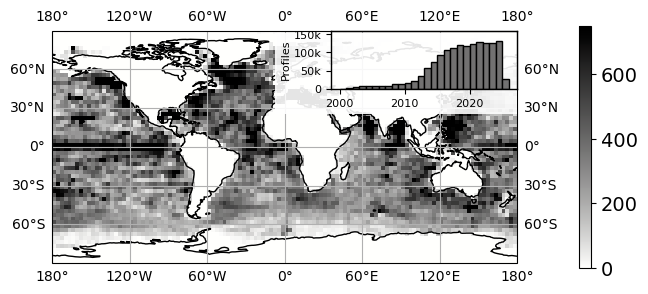

In [10]:
fig = plt.figure(figsize=(8, 3.5))
ax2 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
lon_edges = np.arange(-180, 181, 3)
lat_edges = np.arange(-90, 91, 3)
heatmap, _, _ = np.histogram2d(ds_pbar.LAT.values, ds_pbar.LON.values, bins=[lat_edges, lon_edges])
avg_profiles_3deg = heatmap[heatmap > 0].mean()
std_profiles_3deg = heatmap[heatmap > 0].std()

lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
X, Y = np.meshgrid(lon_centers, lat_centers)

heatmap_plot = ax2.pcolormesh(X, Y, heatmap, cmap=cmo.gray_r, norm=colors.Normalize(vmin=0, vmax=750), transform=ccrs.PlateCarree())
cbar = plt.colorbar(heatmap_plot, ax=ax2, orientation='vertical', pad=0.1, shrink=0.9)
add_profile_bin_inset(ax2, ds_pbar)
#cbar.set_label('Number of Profiles')
ax2.coastlines()
ax2.gridlines(draw_labels=True)
ax2.set_global()

## Data: example Krho

In [100]:
def add_depth_hist_inset(ax, data_all, data_200, data_1000, data_1800, bins, var, step=1):
    """
    Add a two-layer inset histogram:
    - background opaque rectangle
    - foreground histogram inset
    with curves for all depths, 200m, and 1000m.
    """

    # --- 1. Background opaque box ---
    bg = inset_axes(ax, width="100%", height="100%", bbox_to_anchor=(0.65, 0.65, 0.35, 0.35), bbox_transform=ax.transAxes, loc="upper left", borderpad=0)
    bg.set_facecolor((1, 1, 1, 0.90))
    bg.set_xticks([])
    bg.set_yticks([])
    for spine in bg.spines.values():
        spine.set_visible(False)

    # --- 2. Foreground histogram inset ---
    inset = inset_axes(ax, width="100%", height="100%", bbox_to_anchor=(0.66, 0.82, 0.34, 0.18), bbox_transform=ax.transAxes, loc="upper left", borderpad=0)
    inset.set_facecolor((1, 1, 1, 0.0))

    # Histograms
    inset.hist(np.log10(data_all[data_all>0]),   bins=bins, density=True, histtype='step', color='black')
    inset.hist(np.log10(data_200[data_200>0]),   bins=bins, density=True, histtype='step', color='tab:red')
    inset.hist(np.log10(data_1000[data_1000>0]),  bins=bins, density=True, histtype='step', color='tab:green')
    inset.hist(np.log10(data_1800[data_1800>0]),  bins=bins, density=True, histtype='step', color='tab:blue')
    #inset.set_xlim(bins[0],bins[-1])

    # X axis
    xticks = np.arange(bins[0], bins[-1], step)
    inset.set_xticks(xticks)
    inset.set_xticklabels([str(x) for x in xticks], fontsize=8)
    inset.set_xlabel("$log_{10}$"+" (Var. Prod.)", fontsize=10, labelpad=-2)

    # Remove y axis
    inset.set_yticks([])
    inset.set_ylabel("")
    inset.tick_params(axis='y', left=False, right=False, labelleft=False, labelright=False)

    # Frame
    for spine in inset.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

    # --- Inline labels on the left ---
    ymin, ymax = inset.get_ylim()
    x_left = bins[0] - 0.01*(bins[-1] - bins[0])   # a little inside the left edge

    inset.text(x_left, ymin + 0.86*(ymax - ymin), "all", color='black', fontsize=7, ha='left', va='center')
    inset.text(x_left, ymin + 0.61*(ymax - ymin), "200 m", color='tab:red', fontsize=7, ha='left', va='center')
    inset.text(x_left, ymin + 0.36*(ymax - ymin), "1000 m", color='tab:green', fontsize=7, ha='left', va='center')
    inset.text(x_left, ymin + 0.16*(ymax - ymin), "1800 m", color='tab:blue', fontsize=7, ha='left', va='center')

    return inset

depth: 1000 m


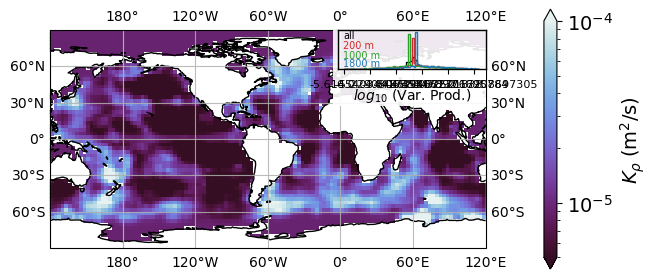

In [101]:
fig = plt.figure(figsize=(7.5, 3.75))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-60))

depth = 1000
shrink, pad = 0.9, 0.1

K_rho_p.sel(PRESSURE_mean=depth, method='nearest').plot(x='LON', y='LAT', cmap=cmo.dense_r, norm=colors.LogNorm(5e-6, 1e-4), transform=ccrs.PlateCarree(), 
                                                        cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': r'$K_\rho \; (\mathrm{m}^2/\mathrm{s})$'}, ax=ax)

all_Krho    = K_rho_p.values.flatten()
Krho200     = K_rho_p.sel(PRESSURE_mean=200,  method='nearest').values.flatten()
Krho1000    = K_rho_p.sel(PRESSURE_mean=1000, method='nearest').values.flatten()
Krho1800    = K_rho_p.sel(PRESSURE_mean=1800, method='nearest').values.flatten()

# Use robust percentiles to focus the inset histogram on the populated range.
log_all = np.log10(all_Krho[all_Krho > 0])
xmin, xmax = np.nanpercentile(log_all, [2, 98])
Krho_bins = np.linspace(-6, -4, 75)
step = (xmax - xmin) / 4

add_depth_hist_inset(ax, data_all=all_Krho, data_200=Krho200, data_1000=Krho1000, data_1800=Krho1800, bins=Krho_bins, var='$(K_{rho})$', step=step)

ax.coastlines()
ax.gridlines(draw_labels=True, alpha=0.85)
ax.set_title('')

print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")
plt.savefig(f"quals_paper/methods/4_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png",dpi=300, bbox_inches='tight')


## Methods: scale-separation plots

LON: -54.81896666666667 LAT: 125.11388166666667


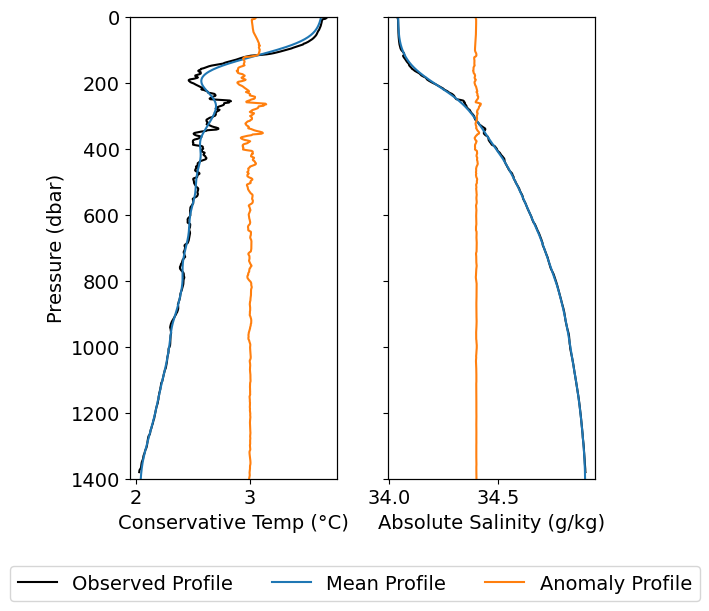

In [102]:
prof = ds_pbar.isel(PROFILE=100000)
fig, axes = plt.subplots(ncols=2, figsize=(6,6), sharey=True)
# LEFT PANEL — CT
ax1 = axes[0]

# Labeled lines (used for legend)
h1 = ax1.plot(prof.CT_sort, prof.PRESSURE_mean, color='k', label='Observed Profile')
h2 = ax1.plot(prof.CT_sort_m, prof.PRESSURE_mean, color='tab:blue', label='Mean Profile')
ax1.set_ylim(1400, 0)
ax1.set_xlabel('Conservative Temp (°C)')
ax1.set_ylabel('Pressure (dbar)')
ax1.set_title('')

# Secondary axis for CT anomaly
ax1b = ax1.twinx()
h3 = ax1b.plot(prof.CT_sort_e + 3, prof.PRESSURE_mean, color='tab:orange', label='Anomaly Profile')
ax1b.set_ylim(1350, 0)
ax1b.set_yticks([])
ax1b.set_ylabel('')
ax1b.tick_params(axis='y', which='both', length=0)


# RIGHT PANEL — SA
ax2 = axes[1]

# SAME colors, but NO labels
ax2.plot(prof.SA_sort, prof.PRESSURE_mean, color='k')
ax2.plot(prof.SA_sort_m, prof.PRESSURE_mean, color='tab:blue')
ax2.set_ylim(1400, 0)
ax2.set_xlabel('Absolute Salinity (g/kg)')
ax2.set_title('')

# Secondary axis for SA anomaly
ax2b = ax2.twinx()
ax2b.plot(prof.SA_sort_e + 34.4, prof.PRESSURE_mean,color='tab:orange')
ax2b.set_ylim(1350, 0)
ax2b.set_yticks([])
ax2b.set_ylabel('')
ax2b.tick_params(axis='y', which='both', length=0)

# COMBINED LEGEND (below figure)
handles = h1 + h2 + h3
labels = [h.get_label() for h in handles]
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3)
#fig.suptitle("Scale Separations", y=0.94, weight='bold', size=18)

plt.subplots_adjust(wspace=0.25)
print(f'LON: {prof.LAT.data} LAT: {prof.LON.data}')
#plt.savefig('quals_paper/methods/3_-55_125', dpi=300, bbox_inches='tight')

## Results: Variance Production @1,000 dbar

depth: 1000 m


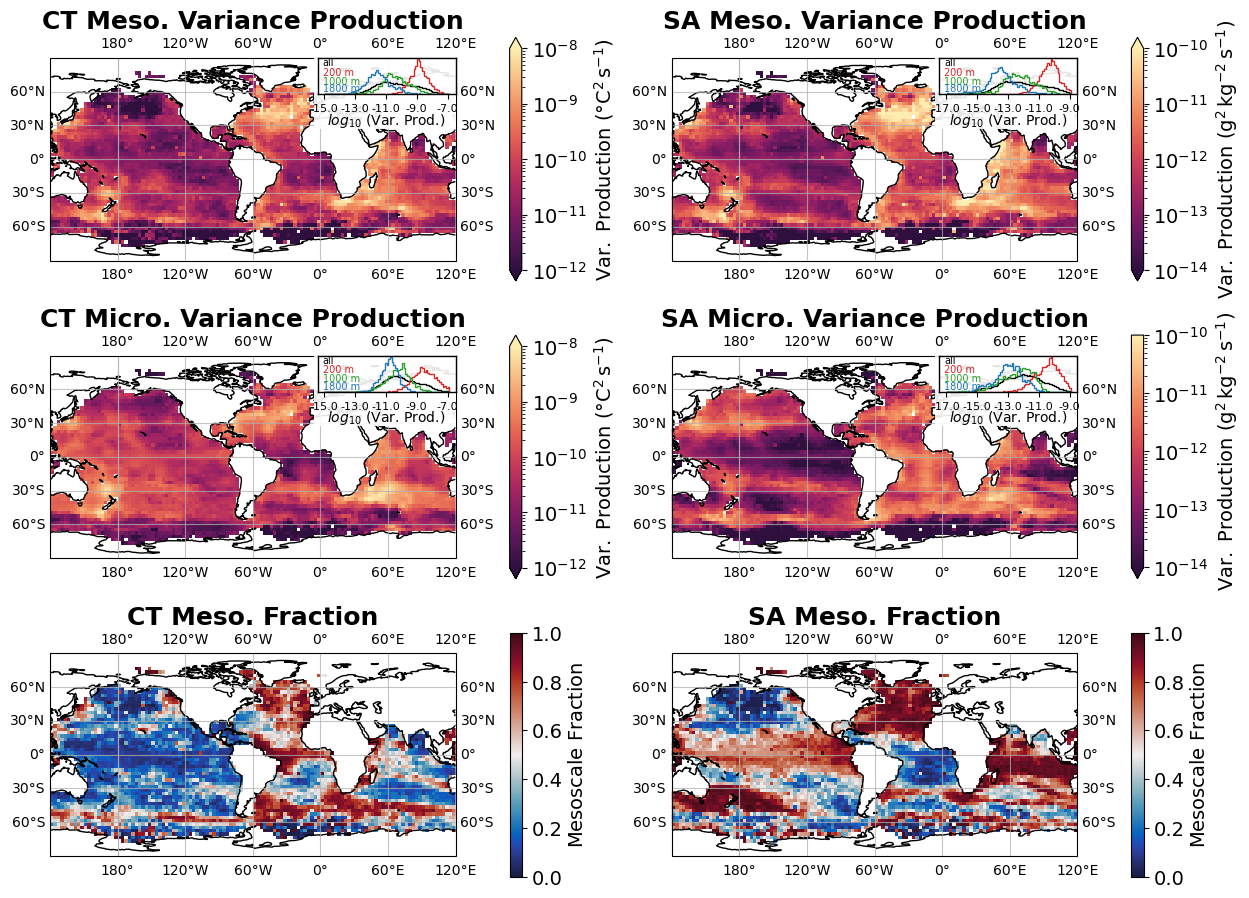

In [106]:
depth = 1000
shrink, pad = 0.9, 0.1

# --- Configuration for each subplot ---
fields = [
    ("CT_e_VPR", cmo.matter_r, (1e-12, 1e-8),  "log", r"$\mathrm{Var.\ Production\ (°C^2\,s^{-1})}$", "CT Meso. Variance Production"),
    ("SA_e_VPR", cmo.matter_r, (1e-14, 1e-10), "log", r"$\mathrm{Var.\ Production\ (g^2\,kg^{-2}\,s^{-1})}$", "SA Meso. Variance Production"),
    ("CT_m_VPR", cmo.matter_r, (1e-12, 1e-8),  "log", r"$\mathrm{Var.\ Production\ (°C^2\,s^{-1})}$", "CT Micro. Variance Production"),
    ("SA_m_VPR", cmo.matter_r, (1e-14, 1e-10), "log", r"$\mathrm{Var.\ Production\ (g^2\,kg^{-2}\,s^{-1})}$", "SA Micro. Variance Production"),
    ("CT_meso_frac", cmo.balance, (0, 1), "linear", r"$\mathrm{Mesoscale\ Fraction}$", "CT Meso. Fraction"),
    ("SA_meso_frac", cmo.balance, (0, 1), "linear", r"$\mathrm{Mesoscale\ Fraction}$", "SA Meso. Fraction"),
]

# Precompute bins for log10(VPR)
bins_CT = np.linspace(-15, -6.9, 75)
bins_SA = np.linspace(-17, -8.9, 75)

# Precompute depth arrays for each variable
def get_depth_arrays(var):
    all_vals    = ds_pbar_grid[var].values.flatten()
    vals_200    = ds_pbar_grid[var].sel(PRESSURE_mean=200,  method='nearest').values.flatten()
    vals_1000   = ds_pbar_grid[var].sel(PRESSURE_mean=1000, method='nearest').values.flatten()
    vals_1800   = ds_pbar_grid[var].sel(PRESSURE_mean=1800, method='nearest').values.flatten()
    return all_vals, vals_200, vals_1000, vals_1800

# --- Helper function to plot each panel ---
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})
    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.75)
    ax.set_title(title)

# --- Create figure and loop ---
fig, axes = plt.subplots(3, 2, figsize=(15, 11.25), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-60)})
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title)

    # Only add histograms to the top two rows (i = 0,1,2,3)
    if i < 4:
        all_vals, vals_200, vals_1000, vals_1800 = get_depth_arrays(var)

        # Choose bins based on variable type
        if var.startswith("CT"):
            bins = bins_CT
        else:
            bins = bins_SA

        add_depth_hist_inset(ax, data_all=all_vals, data_200=vals_200, data_1000=vals_1000, data_1800=vals_1800, bins=bins, var=var, step=2)

plt.subplots_adjust(wspace=0.15, hspace=0.1)
#plt.savefig(f"quals_paper/results/3_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png", dpi=300, bbox_inches='tight')
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")

/tmp/ipykernel_762361/2839413672.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_762361/2839413672.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_762361/2839413672.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_762361/2839413672.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_762361/2839413672.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

lon: -28.5


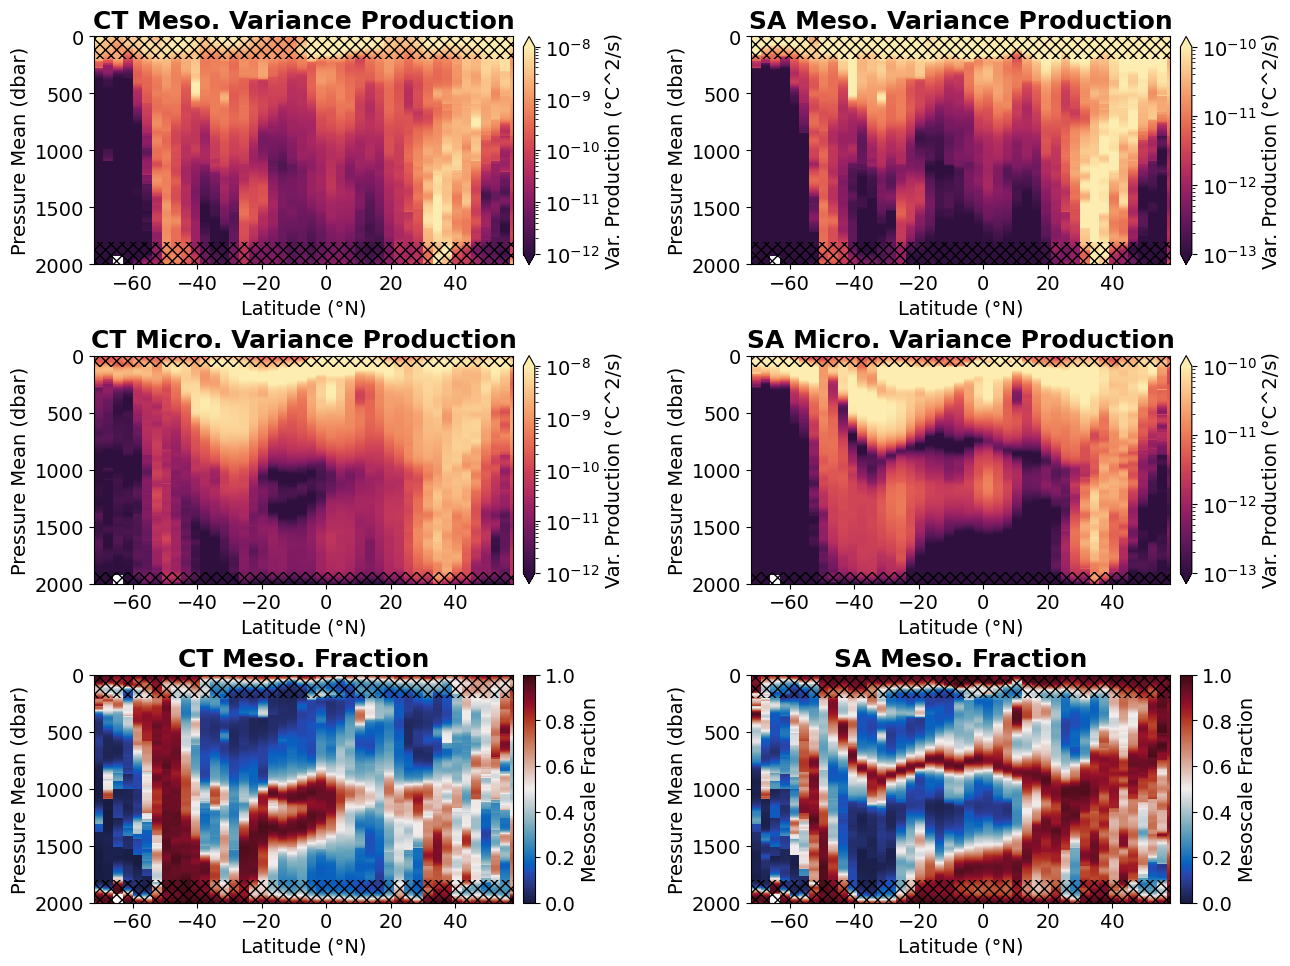

In [150]:
lon = -28
shrink, pad = 1, 0.02

# --- Configuration for each subplot ---
fields = [
    ("CT_e_VPR", cmo.matter_r, (1e-12, 1e-8),  "log", "Var. Production (°C^2/s)", "CT Meso. Variance Production", 200),
    ("SA_e_VPR", cmo.matter_r, (1e-13, 1e-10),  "log", "Var. Production (°C^2/s)", "SA Meso. Variance Production", 200),
    ("CT_m_VPR", cmo.matter_r, (1e-12, 1e-8),  "log", "Var. Production (°C^2/s)", "CT Micro. Variance Production", 100),
    ("SA_m_VPR", cmo.matter_r, (1e-13, 1e-10),  "log", "Var. Production (°C^2/s)", "SA Micro. Variance Production", 100),
    ("CT_meso_frac", cmo.balance, (0, 1),      "linear", "Mesoscale Fraction", "CT Meso. Fraction", 200),
    ("SA_meso_frac", cmo.balance, (0, 1),      "linear", "Mesoscale Fraction", "SA Meso. Fraction", 200),]

# --- Helper function to plot each panel ---
def add_hatching(ax, thickness):
    # Top region (0–thickness)
    ax.axhspan(0, thickness, facecolor='none', edgecolor='k', hatch='xxx', linewidth=0)

    # Bottom region (2000–2000-thickness)
    ax.axhspan(2000 - thickness, 2000, facecolor='none', edgecolor='k', hatch='xxx', linewidth=0)
    
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title, thickness):
    da = ds_pbar_grid[varname].sel(LON=lon, method='nearest')

    # Choose the correct normalization
    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LAT', y='PRESSURE_mean', cmap=cmap, norm=norm, ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.set_xlim(-72, 58)
    ax.set_ylim(2000, 0)
    ax.set_ylabel("Pressure Mean (dbar)")

    ax.set_xlabel("Latitude (°N)")
    ax.set_xticklabels(ax.get_xticklabels())
        
    ax.set_title(title)

    # Add hashed regions
    add_hatching(ax, thickness)

# --- Create figure and loop ---
fig, axes = plt.subplots(3, 2, figsize=(15, 11.25))
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, cmap, vlims, norm_type, cbar_label, title, thickness = fields[i]
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title, thickness)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
#plt.savefig(f"quals_paper/results/4_{ds_pbar_grid.sel(LON=lon, method='nearest').LON.data}.png", dpi=300, bbox_inches='tight')
print(f"lon: {ds_pbar_grid.sel(LON=lon, method='nearest').LON.data}")

## Results: Diffusivity @ many depths

In [132]:
def add_hist_inset(ax, data_all, data_depth, depth_value, bins, var, step=1):
    """
    Add a compact inset histogram with:
      - black curve for ALL depths
      - colored curve for the depth of this map panel

    Colors:
      200 m  -> red
      1000 m -> green
      1800 m -> blue
    """

    # Depth → color mapping
    depth_colors = {200:  "tab:red", 1000: "tab:green", 1800: "tab:blue",}
    depth_color = depth_colors[depth_value]

    # --- 1. Background opaque box ---
    bg = inset_axes(ax, width="100%", height="100%", bbox_to_anchor=(0.65, 0.65, 0.35, 0.35), bbox_transform=ax.transAxes, loc="upper left", borderpad=0)
    bg.set_facecolor((1, 1, 1, 0.90))
    bg.set_xticks([])
    bg.set_yticks([])
    for spine in bg.spines.values():
        spine.set_visible(False)

    # --- 2. Foreground histogram inset ---
    inset = inset_axes(ax, width="100%", height="100%", bbox_to_anchor=(0.66, 0.82, 0.34, 0.18), bbox_transform=ax.transAxes, loc="upper left", borderpad=0)
    inset.set_facecolor((1, 1, 1, 0.0))

    # --- Histograms (density normalized) ---
    inset.hist(np.log10(data_all[data_all > 0]), bins=bins, density=True, histtype='step', color='black', lw=1)
    inset.hist(np.log10(data_depth[data_depth > 0]), bins=bins, density=True, histtype='step', color=depth_color, lw=1)

    # --- X axis ---
    xticks = np.arange(bins[0], bins[-1], step)
    inset.set_xticks(xticks)
    inset.set_xticklabels([str(x) for x in xticks], fontsize=7)
    inset.set_xlabel(r"$\log_{10}$" + f" {var}", fontsize=8, labelpad=-3)

    # --- Remove y axis ---
    inset.set_yticks([])
    inset.tick_params(axis='y', left=False, right=False)

    # --- Frame ---
    for spine in inset.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    # --- Inline labels (only two curves now) ---
    ymin, ymax = inset.get_ylim()
    x_left = bins[0] - 0.02 * (bins[-1] - bins[0])

    inset.text(x_left, ymin + 0.80*(ymax - ymin), "all", color='black', fontsize=7, ha='left', va='center')

    inset.text(x_left, ymin + 0.45*(ymax - ymin), f"{depth_value} m", color=depth_color, fontsize=7, ha='left', va='center')

    return inset

depth: 1800 m


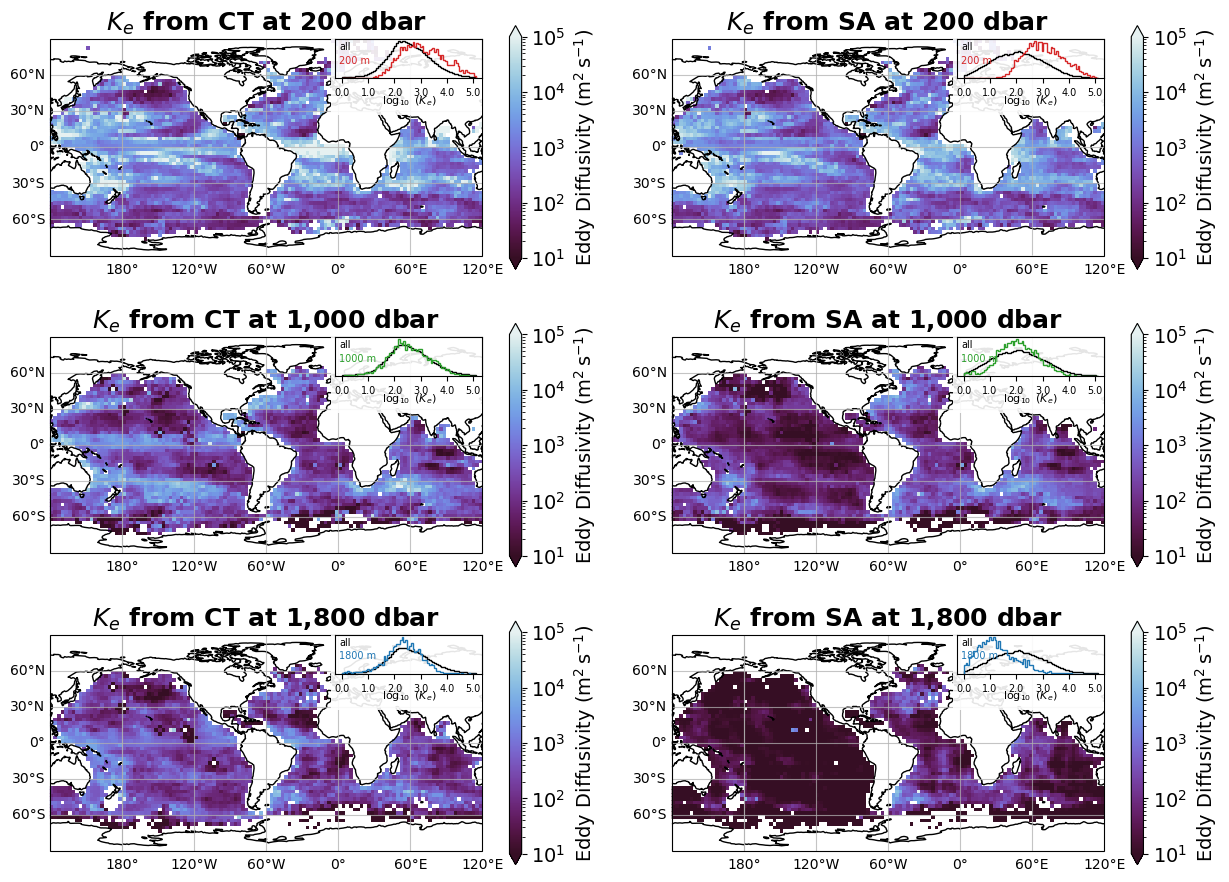

In [133]:
shrink, pad = 0.9, 0.05

# --- Configuration for each subplot ---
fields = [
    ("K_e_CT", 200, cmo.dense_r, (1e1, 1e5),  "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", r"$\boldsymbol{K_e}$ from CT at 200 dbar"),
    ("K_e_SA", 200, cmo.dense_r, (1e1, 1e5), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", r"$\boldsymbol{K_e}$ from SA at 200 dbar"),
    ("K_e_CT", 1000, cmo.dense_r, (1e1, 1e5),  "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", r"$\boldsymbol{K_e}$ from CT at 1,000 dbar"),
    ("K_e_SA", 1000, cmo.dense_r, (1e1, 1e5), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", r"$\boldsymbol{K_e}$ from SA at 1,000 dbar"),
    ("K_e_CT", 1800, cmo.dense_r, (1e1, 1e5), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", r"$\boldsymbol{K_e}$ from CT at 1,800 dbar"),
    ("K_e_SA", 1800, cmo.dense_r, (1e1, 1e5), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", r"$\boldsymbol{K_e}$ from SA at 1,800 dbar"),
]

# --- Helper function to plot each panel ---
def plot_panel(ax, varname, depth, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose the correct normalization
    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, alpha=0.75)
    gl.top_labels, gl.right_labels = False, False

    # Title inside panel
    ax.set_title(title)

# Precompute bins
bins = np.linspace(0, 5.1, 75)

# Flattened arrays
all_CT    = ds_pbar_grid.K_e_CT.values.flatten()
all_SA    = ds_pbar_grid.K_e_SA.values.flatten()

Ke200_CT  = ds_pbar_grid.K_e_CT.sel(PRESSURE_mean=200,  method='nearest').values.flatten()
Ke1000_CT = ds_pbar_grid.K_e_CT.sel(PRESSURE_mean=1000, method='nearest').values.flatten()
Ke1800_CT = ds_pbar_grid.K_e_CT.sel(PRESSURE_mean=1800, method='nearest').values.flatten()

Ke200_SA  = ds_pbar_grid.K_e_SA.sel(PRESSURE_mean=200,  method='nearest').values.flatten()
Ke1000_SA = ds_pbar_grid.K_e_SA.sel(PRESSURE_mean=1000, method='nearest').values.flatten()
Ke1800_SA = ds_pbar_grid.K_e_SA.sel(PRESSURE_mean=1800, method='nearest').values.flatten()

fig, axes = plt.subplots(3, 2, figsize=(15, 11.25), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-60)})
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, depth, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, depth, cmap, vlims, norm_type, cbar_label, title)

    # --- Select the correct depth-specific array ---
    if var == "K_e_CT":
        depth_array = {200: Ke200_CT, 1000: Ke1000_CT, 1800: Ke1800_CT}[depth]
        add_hist_inset(ax, all_CT, depth_array, depth, bins, '$(K_e)$')

    else:  # K_e_SA
        depth_array = {200: Ke200_SA, 1000: Ke1000_SA, 1800: Ke1800_SA}[depth]
        add_hist_inset(ax, all_SA, depth_array, depth, bins, '$(K_e)$')

plt.subplots_adjust(wspace=0.15, hspace=0.1)
#plt.savefig(f"quals_paper/results/5_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png", dpi=300, bbox_inches='tight')
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")

## Results: All Flux Maps

depth: 1000


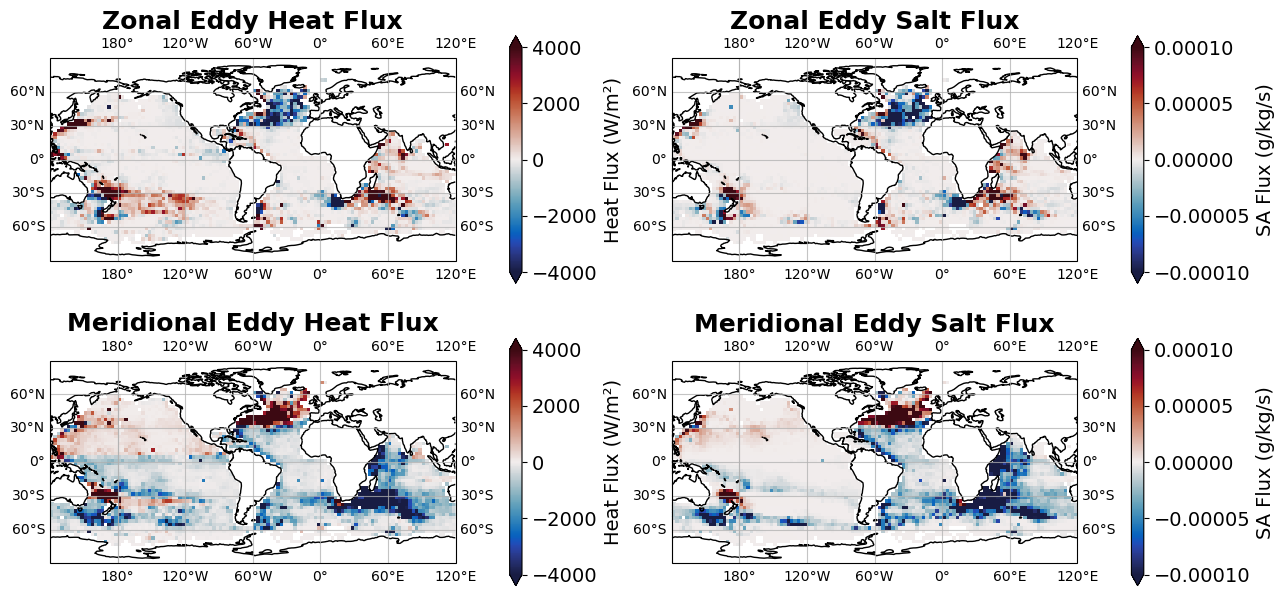

In [159]:
depth = 1000
shrink, pad = 0.9, 0.1

# --- Configuration for each subplot ---
fields = [
    ("F_heat_x", cmo.balance, (-4e3, 4e3), "lin", "Heat Flux (W/m²)", "Zonal Eddy Heat Flux"),
    ("F_SA_x",   cmo.balance, (-1e-4,1e-4), "lin", "SA Flux (g/kg/s)", "Zonal Eddy Salt Flux"),
    ("F_heat_y", cmo.balance, (-4e3, 4e3), "lin", "Heat Flux (W/m²)", "Meridional Eddy Heat Flux"),
    ("F_SA_y",   cmo.balance, (-1e-4,1e-4), "lin", "SA Flux (g/kg/s)", "Meridional Eddy Salt Flux"),]


# --- Helper function to plot each panel ---
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose normalization
    if norm_type == "symlog":
        linthresh = vlims[0]  # linear region around zero
        vmax = vlims[1]
        norm = SymLogNorm(
            linthresh=linthresh,
            vmin=-vmax,
            vmax=vmax)
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    # --- Base map ---
    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    # --- Decorations ---
    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.75)
    ax.set_title(title)


# --- Create figure and loop ---
fig, axes = plt.subplots(
    2, 2, figsize=(15, 7.5),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-60)}
)
axes = axes.ravel()

for i, ax in enumerate(axes[:len(fields)]):
    var, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title)

# Hide the extra subplot
for ax in axes[len(fields):]:
    ax.set_visible(False)

plt.subplots_adjust(wspace=0.15, hspace=0.1)
#plt.savefig(f"quals_paper/results/7_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png", dpi=300, bbox_inches='tight')
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}")

## Results: Meridional Flux Maps

depth: 1800 m


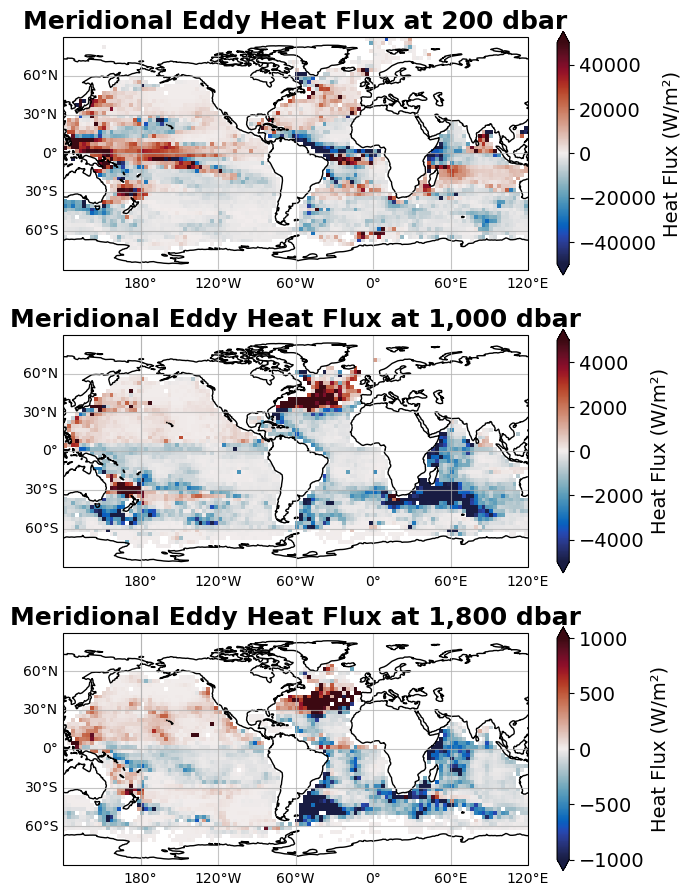

In [157]:
depth = 1000
shrink, pad = 0.9, 0.05

# --- Configuration for each subplot ---
fields = [
    ("F_heat_y", 200, cmo.balance, (-5e4, 5e4), "lin", "Heat Flux (W/m²)", "Meridional Eddy Heat Flux at 200 dbar"),
    ("F_heat_y", 1000, cmo.balance, (-5e3, 5e3), "lin", "Heat Flux (W/m²)", "Meridional Eddy Heat Flux at 1,000 dbar"),
    ("F_heat_y", 1800, cmo.balance, (-1e3, 1e3), "lin", "Heat Flux (W/m²)", "Meridional Eddy Heat Flux at 1,800 dbar"),
]

# --- Helper function to plot each panel ---
def plot_panel(ax, varname, depth, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose the correct normalization
    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, alpha=0.75)
    gl.top_labels, gl.right_labels = False, False

    # Title inside panel
    ax.set_title(title)


fig, axes = plt.subplots(3, 1, figsize=(7.5, 11.25), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-60)})
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, depth, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, depth, cmap, vlims, norm_type, cbar_label, title)


plt.subplots_adjust(wspace=0.15, hspace=0.1)
#plt.savefig(f"quals_paper/results/5_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png", dpi=300, bbox_inches='tight')
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")

/tmp/ipykernel_762361/133059287.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_762361/133059287.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_762361/133059287.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())


lon: 79.5


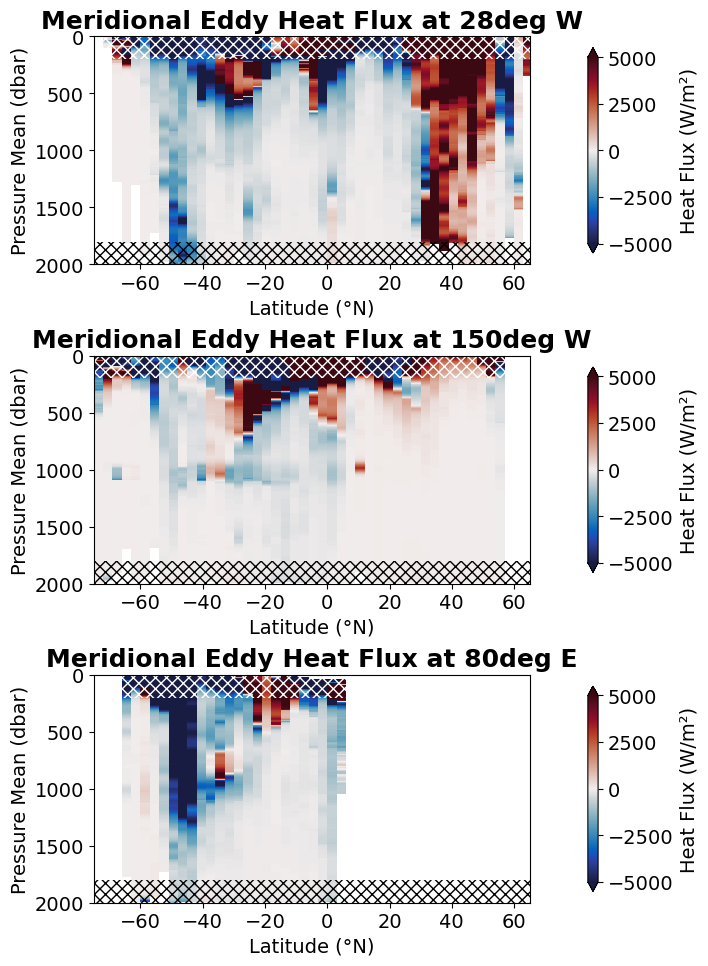

In [171]:
## shrink, pad = 1, 0.02

# --- Configuration for each subplot ---
fields = [
    ("F_heat_y", -28, cmo.balance, (-5e3, 5e3), "lin", "Heat Flux (W/m²)", "Meridional Eddy Heat Flux at 28deg W",  200),
    ("F_heat_y", -150, cmo.balance, (-5e3, 5e3), "lin", "Heat Flux (W/m²)", "Meridional Eddy Heat Flux at 150deg W", 200),
    ("F_heat_y", 80, cmo.balance, (-5e3, 5e3), "lin", "Heat Flux (W/m²)", "Meridional Eddy Heat Flux at 80deg E", 200),
]


# --- Helper function to add hatching ---
def add_hatching(ax, thickness):
    ax.axhspan(0, thickness, facecolor='none', edgecolor='white', hatch='xxx', linewidth=0)
    ax.axhspan(2000 - thickness, 2000, facecolor='none', edgecolor='k', hatch='xxx', linewidth=0)


# --- Helper function to plot each panel ---
def plot_panel(ax, varname, lon, cmap, vlims, norm_type, cbar_label, title, thickness):
    da = ds_pbar_grid[varname].sel(LON=lon, method='nearest')

    # --- Normalization ---
    if norm_type == "symlog":
        vmin, vmax = vlims
        # Widen the linear region so the center isn't too dark
        linthresh = vmin * 50   # adjust factor as needed
        norm = SymLogNorm(linthresh=linthresh, vmin=-vmax, vmax=vmax)
        
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    # --- Base plot ---
    da.plot(x='LAT', y='PRESSURE_mean', cmap=cmap, norm=norm, ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    # --- Axes formatting ---
    ax.set_xlim(-75, 65)
    ax.set_ylim(2000, 0)
    ax.set_ylabel("Pressure Mean (dbar)")

    ax.set_xlabel("Latitude (°N)")
    ax.set_xticklabels(ax.get_xticklabels())

    ax.set_title(title)

    # --- Add hashed regions ---
    add_hatching(ax, thickness)


# --- Create figure and loop ---
fig, axes = plt.subplots(3, 1, figsize=(7.5, 11.25))
axes = axes.ravel()

for i, ax in enumerate(axes[:len(fields)]):
    var, lon, cmap, vlims, norm_type, cbar_label, title, thickness = fields[i]
    plot_panel(ax, var, lon, cmap, vlims, norm_type, cbar_label, title, thickness)

# Hide unused subplot
for ax in axes[len(fields):]:
    ax.set_visible(False)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
#plt.savefig(f"quals_paper/results/8_{ds_pbar_grid.sel(LON=lon, method='nearest').LON.data}.png", dpi=300, bbox_inches='tight')
print(f"lon: {ds_pbar_grid.sel(LON=lon, method='nearest').LON.data}")

## Meridional Eddy Heat Transport

In [160]:
ds_pbar_grad

<xarray.Dataset>
Dimensions:          (LON: 120, LAT: 60, PRESSURE_mean: 1001, LON_left: 120,
                      LAT_left: 60)
Coordinates:
  * LON              (LON) float64 -178.5 -175.5 -172.5 ... 172.5 175.5 178.5
  * LAT              (LAT) float64 -88.5 -85.5 -82.5 -79.5 ... 82.5 85.5 88.5
  * PRESSURE_mean    (PRESSURE_mean) int64 0 2 4 6 8 ... 1994 1996 1998 2000
  * LON_left         (LON_left) float64 -180.0 -177.0 -174.0 ... 174.0 177.0
  * LAT_left         (LAT_left) float64 -90.0 -87.0 -84.0 ... 81.0 84.0 87.0
Data variables: (12/33)
    CT_m_bin         (PRESSURE_mean, LON, LAT) float64 ...
    SA_m_bin         (PRESSURE_mean, LON, LAT) float64 ...
    SPICE_m_bin      (PRESSURE_mean, LON, LAT) float64 ...
    DENSITY          (PRESSURE_mean, LON, LAT) float64 ...
    dCT_m_dx         (PRESSURE_mean, LON, LAT) float64 ...
    dCT_m_dy         (PRESSURE_mean, LON, LAT) float64 ...
    ...               ...
    F_SPICE_y        (PRESSURE_mean, LON, LAT) float64 ...
    F_SPICE_xy       (PRESSURE_mean, LON, LAT) float64 ...
    Cp               (PRESSURE_mean, LON, LAT) float64 ...
    F_heat_x         (PRESSURE_mean, LON, LAT) float64 ...
    F_heat_y         (PRESSURE_mean, LON, LAT) float64 ...
    F_heat_xy        (PRESSURE_mean, LON, LAT) float64 ...

In [ ]:
# ---------------------------------------------------------
# Compute zonal metric Δx
# ---------------------------------------------------------
R = 6371e3
dlon = np.deg2rad(float(ds_pbar_grid.LON[1] - ds_pbar_grid.LON[0]))
lat_rad = np.deg2rad(ds_pbar_grid.LAT)

dx = R * np.cos(lat_rad) * dlon
dx_da = xr.DataArray(dx, dims=['LAT'])
dx_3d = dx_da.broadcast_like(ds_pbar_grid.F_heat_y)

# ---------------------------------------------------------
# Add constant Δz (m)
# ---------------------------------------------------------
delta_z = 2.0   # choose your constant vertical thickness (meters)

# ---------------------------------------------------------
# Compute basin-specific meridional heat transport
# ---------------------------------------------------------
hFy_dx_dz = ds_pbar_grad.F_heat_y.sel(PRESSURE_mean=slice(200,2000)) * dx_3d * delta_z

htransport_atl    = hFy_dx_dz.where(ds_pbar_grad.basin==1).sum(dim=['PRESSURE_mean', 'LON'])
htransport_pac    = hFy_dx_dz.where(ds_pbar_grad.basin==2).sum(dim=['PRESSURE_mean', 'LON'])
htransport_ind    = hFy_dx_dz.where(ds_pbar_grad.basin==3).sum(dim=['PRESSURE_mean', 'LON'])
htransport_sou    = hFy_dx_dz.where(ds_pbar_grad.basin==10).sum(dim=['PRESSURE_mean', 'LON'])
htransport_art    = hFy_dx_dz.where(ds_pbar_grad.basin==11).sum(dim=['PRESSURE_mean', 'LON'])
htransport_global = hFy_dx_dz.where(ds_pbar_grad.basin.isin([1, 2, 3, 10, 11])).sum(dim=['PRESSURE_mean', 'LON'])

# ---------------------------------------------------------
# Compute basin-specific meridional salt transport
# ---------------------------------------------------------
sFy_dx_dz = ds_pbar_grad.F_SA_y.sel(PRESSURE_mean=slice(200,2000)) * dx_3d * delta_z

stransport_atl    = sFy_dx_dz.where(ds_pbar_grad.basin==1).sum(dim=['PRESSURE_mean', 'LON'])
stransport_pac    = sFy_dx_dz.where(ds_pbar_grad.basin==2).sum(dim=['PRESSURE_mean', 'LON'])
stransport_ind    = sFy_dx_dz.where(ds_pbar_grad.basin==3).sum(dim=['PRESSURE_mean', 'LON'])
stransport_sou    = sFy_dx_dz.where(ds_pbar_grad.basin==10).sum(dim=['PRESSURE_mean', 'LON'])
stransport_art    = sFy_dx_dz.where(ds_pbar_grad.basin==11).sum(dim=['PRESSURE_mean', 'LON'])
stransport_global = sFy_dx_dz.where(ds_pbar_grad.basin.isin([1, 2, 3, 10, 11])).sum(dim=['PRESSURE_mean', 'LON'])

# ---------------------------------------------------------
# Plot all curves (two subplots)
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3), sharey=False)

# -------------------------
# Left panel: Heat transport
# -------------------------
ax1.plot(ds_pbar_grid.LAT, htransport_global / 1e15, label='Global',   color='k', linewidth=3)
ax1.plot(ds_pbar_grid.LAT, htransport_pac    / 1e15, label='Pacific',  color='tab:red')
ax1.plot(ds_pbar_grid.LAT, htransport_atl    / 1e15, label='Atlantic', color='tab:orange')
ax1.plot(ds_pbar_grid.LAT, htransport_ind    / 1e15, label='Indian',   color='tab:green')
ax1.plot(ds_pbar_grid.LAT, htransport_sou    / 1e15, label='Southern', color='tab:blue')
ax1.plot(ds_pbar_grid.LAT, htransport_art    / 1e15, label='Arctic',   color='tab:purple')

ax1.axhline(0, color='k', linewidth=1, linestyle='--')
ax1.set_xlim(-75,65)
ax1.set_xlabel('Latitude')
ax1.set_ylabel('Heat Transport (PW)')
#ax1.set_title('Meridional Heat Transport')

# -------------------------
# Right panel: Salt transport
# -------------------------
ax2.plot(ds_pbar_grid.LAT, stransport_global / 1e6, label='Global',   color='k', linewidth=3)
ax2.plot(ds_pbar_grid.LAT, stransport_pac    / 1e6, label='Pacific',  color='tab:red')
ax2.plot(ds_pbar_grid.LAT, stransport_atl    / 1e6, label='Atlantic', color='tab:orange')
ax2.plot(ds_pbar_grid.LAT, stransport_ind    / 1e6, label='Indian',   color='tab:green')
ax2.plot(ds_pbar_grid.LAT, stransport_sou    / 1e6, label='Southern', color='tab:blue')
ax2.plot(ds_pbar_grid.LAT, stransport_art    / 1e6, label='Arctic',   color='tab:purple')

ax2.axhline(0, color='k', linewidth=1, linestyle='--')
ax2.set_xlim(-75,65)
ax2.set_xlabel('Latitude')
ax2.set_ylabel('Salt Transport (UNIT)')
#ax2.set_title('Meridional Salt Transport')

# -------------------------
# Legend (shared)
# -------------------------
ax2.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))


plt.subplots_adjust(wspace=0.25)